Brain Tumour Segmentation in MRI with U-Net.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q segmentation-models-pytorch kagglehub

import torch
print("GPU available:", torch.cuda.is_available())

from google.colab import drive
drive.mount("/content/drive")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00
GPU available: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Download Dataset
Download the LGG MRI segmentation dataset via kagglehub, remove duplicates, and index matching slice-mask pairs by patient.

In [ ]:
import kagglehub, glob, os

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print("Downloaded to:", path)

# List all masks, and remove duplicate copies of the same file
mask_files = glob.glob(os.path.join(path, "**", "*_mask.tif"), recursive=True)
unique = {}
for m in mask_files:
    unique.setdefault(os.path.basename(m), m)
mask_files = sorted(unique.values())

# For each mask, find its image and its patient
image_files = [m.replace("_mask.tif", ".tif") for m in mask_files]
patients = [os.path.basename(os.path.dirname(m)) for m in mask_files]

print(len(image_files), "slices from", len(set(patients)), "patients")

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Downloaded to: /kaggle/input/lgg-mri-segmentation
3929 slices from 110 patients


### Step 3: Data Exploration
Inspect slices with and without tumours visually and verify image-mask alignment with an overlay plot.

Slices with tumour:    1373
Slices without tumour: 2556


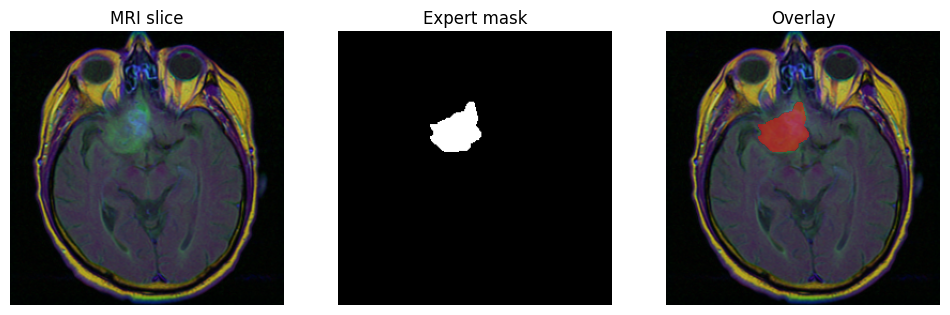

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt
has_tumour = np.array([cv2.imread(m, 0).max() > 0 for m in mask_files])
print("Slices with tumour:   ", has_tumour.sum())
print("Slices without tumour:", (~has_tumour).sum())
i = int(np.where(has_tumour)[0][0])                   # first slice with a tumour
img  = cv2.imread(image_files[i])[:, :, ::-1]         # OpenCV reads BGR -> convert to RGB
mask = cv2.imread(mask_files[i], 0)                   # 0 = read as grayscale
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img);                ax[0].set_title("MRI slice")
ax[1].imshow(mask, cmap="gray");  ax[1].set_title("Expert mask")
ax[2].imshow(img)
ax[2].imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.5)
ax[2].set_title("Overlay")
for a in ax: a.axis("off")
plt.show()

### Step 4: Patient-Level Split
Split the dataset into train (70%), validation (15%), and test (15%) sets strictly by patient to prevent data leakage between adjacent slices.

In [ ]:
rng = np.random.default_rng(42)            # fixed seed -> same split every time
ids = np.array(sorted(set(patients)))
rng.shuffle(ids)
n = len(ids)
train_ids = set(ids[:int(0.70 * n)])
val_ids   = set(ids[int(0.70 * n):int(0.85 * n)])
test_ids  = set(ids[int(0.85 * n):])
assert not (train_ids & test_ids) and not (train_ids & val_ids)   # no shared patient
def pick(id_set):
    idx = [k for k, p in enumerate(patients) if p in id_set]
    return [image_files[k] for k in idx], [mask_files[k] for k in idx]
train_imgs, train_masks = pick(train_ids)
val_imgs,   val_masks   = pick(val_ids)
test_imgs,  test_masks  = pick(test_ids)
print(len(train_ids), len(val_ids), len(test_ids), "patients")
print(len(train_imgs), len(val_imgs), len(test_imgs), "slices")

77 16 17 patients
2714 615 600 slices


### Step 5: PyTorch Dataset & DataLoaders
Build a custom PyTorch Dataset with optional horizontal flip augmentation and wrap it into DataLoaders for batching.

In [ ]:
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import torch

# Define normalization constants
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

class MRIDataset(Dataset):
    def __init__(self, imgs, masks, augment=False):
        self.imgs, self.masks, self.augment = imgs, masks, augment

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img  = cv2.imread(self.imgs[i])[:, :, ::-1] / 255.0
        mask = (cv2.imread(self.masks[i], 0) > 127).astype(np.float32)
        if self.augment and np.random.rand() < 0.5:
            img, mask = img[:, ::-1], mask[:, ::-1]
        img = (img - mean) / std
        img = torch.tensor(img.copy(), dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask.copy()).unsqueeze(0)
        return img, mask

train_loader = DataLoader(MRIDataset(train_imgs, train_masks, augment=True),
                          batch_size=16, shuffle=True, num_workers=2)
val_loader  = DataLoader(MRIDataset(val_imgs, val_masks),   batch_size=16)
test_loader = DataLoader(MRIDataset(test_imgs, test_masks), batch_size=16)

x, y = next(iter(train_loader))
print(x.mean().item(), x.std().item())

-1.559106469154358 0.5911466479301453


### Step 6: Model Architecture & Loss Function
Initialize a U-Net with a pretrained ResNet-34 encoder and define a combined Dice + BCE loss with the Adam optimizer.

In [ ]:
import segmentation_models_pytorch as smp
device = "cuda"
model = smp.Unet(encoder_name="resnet34", encoder_weights=None,   # <- no pretraining
                 in_channels=3, classes=1).to(device)
dice_loss = smp.losses.DiceLoss(mode="binary")      # works directly on the raw outputs
bce_loss  = torch.nn.BCEWithLogitsLoss()
def loss_fn(logits, y):
    return dice_loss(logits, y) + bce_loss(logits, y)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

### Step 7: Dice Evaluation Metric
Define the per-image Dice coefficient metric and an evaluation function to track validation and test performance across batches.

In [ ]:
def dice_per_image(logits, y, eps=1e-6):
    pred = (torch.sigmoid(logits) > 0.5).float()
    inter = (pred * y).sum(dim=(1, 2, 3))
    total = pred.sum(dim=(1, 2, 3)) + y.sum(dim=(1, 2, 3))
    return (2 * inter + eps) / (total + eps)

def evaluate(loader):
    model.eval()
    scores = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            scores.append(dice_per_image(model(x), y).cpu())
    return torch.cat(scores).numpy()

### Step 8: Model Training
Train the model for 25 epochs using combined Dice + BCE loss, monitoring validation Dice to save the best checkpoint to Google Drive.

In [ ]:
save_path = "/content/drive/MyDrive/unet_scratch_best.pt"
best = 0
for epoch in range(25):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = loss_fn(model(x), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    val_dice = evaluate(val_loader).mean()
    print(f"epoch {epoch+1:2d} | last loss {loss.item():.3f} | val Dice {val_dice:.3f}")
    if val_dice > best:
        best = val_dice
        torch.save(model.state_dict(), save_path)       # saved to Drive

epoch  1 | last loss 1.031 | val Dice 0.716
epoch  2 | last loss 0.620 | val Dice 0.683
epoch  3 | last loss 0.179 | val Dice 0.782
epoch  4 | last loss 0.424 | val Dice 0.804
epoch  5 | last loss 0.196 | val Dice 0.778
epoch  6 | last loss 0.211 | val Dice 0.788
epoch  7 | last loss 0.134 | val Dice 0.786
epoch  8 | last loss 0.277 | val Dice 0.803
epoch  9 | last loss 0.094 | val Dice 0.783
epoch 10 | last loss 0.111 | val Dice 0.771
epoch 11 | last loss 0.648 | val Dice 0.792
epoch 12 | last loss 0.242 | val Dice 0.801
epoch 13 | last loss 0.117 | val Dice 0.802
epoch 14 | last loss 0.234 | val Dice 0.797
epoch 15 | last loss 0.867 | val Dice 0.794
epoch 16 | last loss 0.136 | val Dice 0.785
epoch 17 | last loss 0.108 | val Dice 0.806
epoch 18 | last loss 0.209 | val Dice 0.732
epoch 19 | last loss 0.088 | val Dice 0.801
epoch 20 | last loss 0.132 | val Dice 0.808
epoch 21 | last loss 0.073 | val Dice 0.770
epoch 22 | last loss 0.149 | val Dice 0.805
epoch 23 | last loss 0.106 | val

### Step 9: Test Evaluation & Qualitative Inspection
Evaluate the best model checkpoint on the unseen test set, report Dice/IoU scores (overall and tumour-only), and plot qualitative best and worst predictions.

Dice, all test slices:    0.872
Dice, tumour slices only: 0.713
IoU,  tumour slices only: 0.554


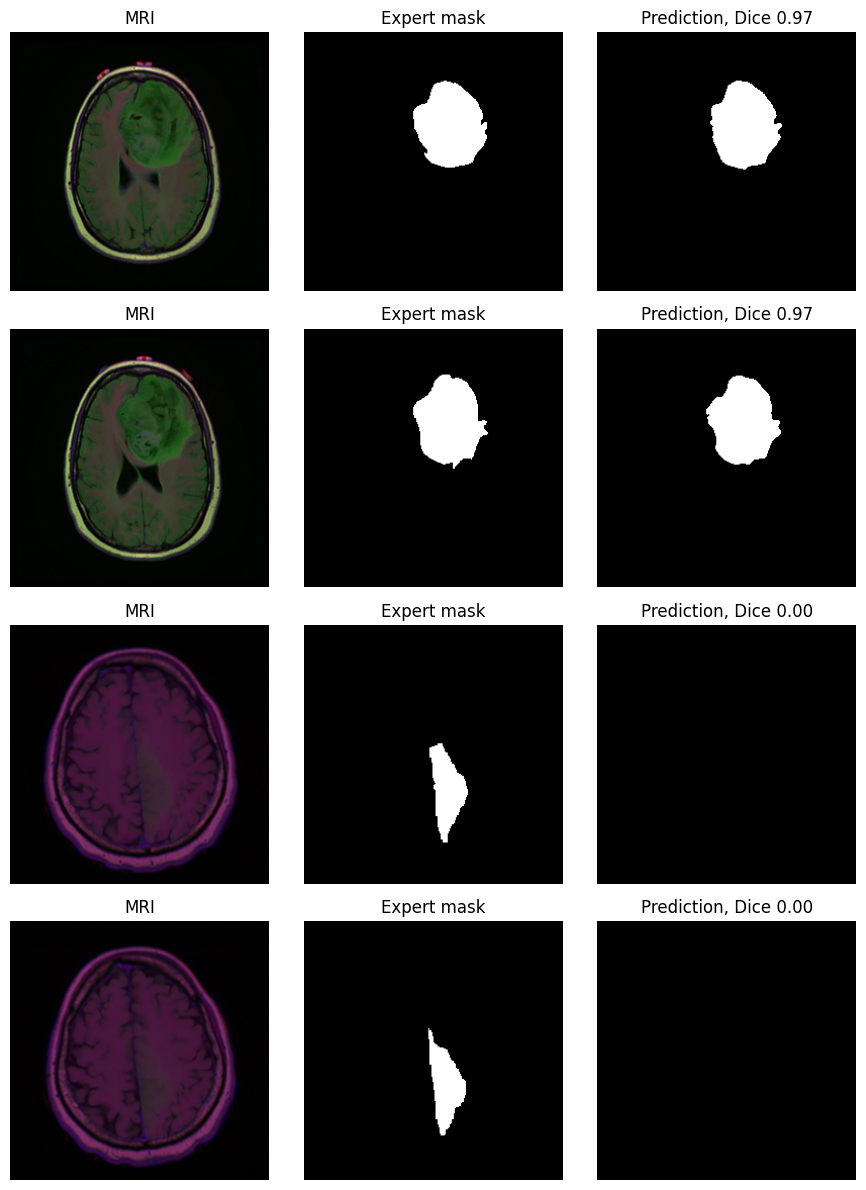

In [ ]:
model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1).to(device)
model.load_state_dict(torch.load(save_path))
scores = evaluate(test_loader)
tumour = np.array([cv2.imread(m, 0).max() > 0 for m in test_masks])

print(f"Dice, all test slices:    {scores.mean():.3f}")
print(f"Dice, tumour slices only: {scores[tumour].mean():.3f}")
d = scores[tumour].mean()
print(f"IoU,  tumour slices only: {d / (2 - d):.3f}")    # approximate, from mean Dice

test_ds = MRIDataset(test_imgs, test_masks)
worst = np.where(tumour)[0][np.argsort(scores[tumour])[:2]]    # 2 worst tumour slices
best_ = np.where(tumour)[0][np.argsort(scores[tumour])[-2:]]   # 2 best tumour slices
rows = list(best_) + list(worst)

model.eval()
fig, ax = plt.subplots(len(rows), 3, figsize=(9, 3 * len(rows)))
for r, k in enumerate(rows):
    x, y = test_ds[k]
    with torch.no_grad():
        p = torch.sigmoid(model(x[None].to(device)))[0, 0].cpu() > 0.5
    ax[r, 0].imshow(cv2.imread(test_imgs[k])[:, :, ::-1]); ax[r, 0].set_title("MRI")
    ax[r, 1].imshow(y[0], cmap="gray");  ax[r, 1].set_title("Expert mask")
    ax[r, 2].imshow(p, cmap="gray");     ax[r, 2].set_title(f"Prediction, Dice {scores[k]:.2f}")
    for a in ax[r]: a.axis("off")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/predictions.png", dpi=120, bbox_inches="tight")
plt.show()

### Error Analysis & Mitigation: Tumour Size, Threshold Tuning & Focal Tversky Loss
Analyze performance by lesion size, optimize the decision threshold on validation data, and introduce Focal Tversky Loss to heavily penalize missed tumours.

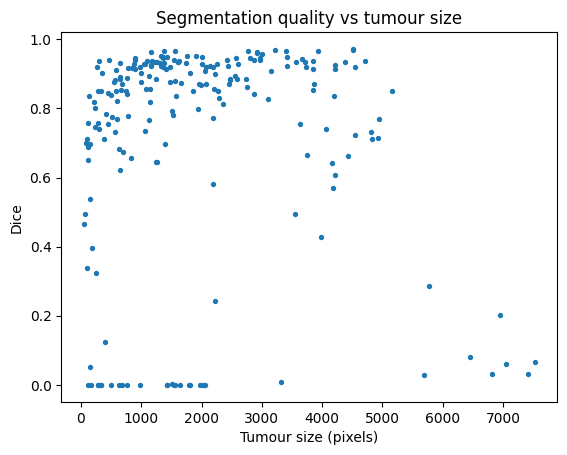

small  tumours: mean Dice = 0.639 | completely missed (Dice < 0.01) = 15%
medium tumours: mean Dice = 0.745 | completely missed (Dice < 0.01) = 15%
large  tumours: mean Dice = 0.753 | completely missed (Dice < 0.01) = 1%
threshold 0.5: val Dice (tumour slices) = 0.540
threshold 0.4: val Dice (tumour slices) = 0.542
threshold 0.3: val Dice (tumour slices) = 0.545
threshold 0.2: val Dice (tumour slices) = 0.547


In [ ]:
sizes = np.array([(cv2.imread(m, 0) > 127).sum() for m in test_masks])

plt.scatter(sizes[tumour], scores[tumour], s=8)
plt.xlabel("Tumour size (pixels)"); plt.ylabel("Dice")
plt.title("Segmentation quality vs tumour size")
plt.savefig("dice_vs_tumour_size.png", dpi=120)
plt.show()

# Average Dice for small / medium / large tumours
s, d = sizes[tumour], scores[tumour]
cuts = np.percentile(s, [0, 33, 66, 100])
for i, name in enumerate(["small", "medium", "large"]):
    m = (s >= cuts[i]) & (s <= cuts[i + 1])
    print(f"{name:6s} tumours: mean Dice = {d[m].mean():.3f} | "
          f"completely missed (Dice < 0.01) = {(d[m] < 0.01).mean() * 100:.0f}%")


# ------------------------------------------------------------
# CELL 2: does a LOWER THRESHOLD help?
# Important: we test it on the VALIDATION set, not the test set.
# (Your guide says: never choose anything using the test set.)
# ------------------------------------------------------------
def dice_at_threshold(loader, thr):
    model.eval()
    out = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            p = (torch.sigmoid(model(x)) > thr).float()
            inter = (p * y).sum(dim=(1, 2, 3))
            total = p.sum(dim=(1, 2, 3)) + y.sum(dim=(1, 2, 3))
            out.append(((2 * inter + 1e-6) / (total + 1e-6)).cpu())
    return torch.cat(out).numpy()

val_tumour = np.array([cv2.imread(m, 0).max() > 0 for m in val_masks])

for thr in [0.5, 0.4, 0.3, 0.2]:
    sc = dice_at_threshold(val_loader, thr)
    print(f"threshold {thr}: val Dice (tumour slices) = {sc[val_tumour].mean():.3f}")

# If a lower threshold is clearly better on validation, pick it,
# then report the test score ONE time with that threshold:
# best_thr = 0.3
# sc_test = dice_at_threshold(test_loader, best_thr)
# print("Test Dice, tumour slices:", sc_test[tumour].mean())


# ------------------------------------------------------------
# CELL 3: THE FIX -> a loss that punishes missed tumours more
# Run this cell, then redo Step 6, Step 8 and Step 9.
# ------------------------------------------------------------
def focal_tversky_loss(logits, y, alpha=0.7, beta=0.3, gamma=0.75, eps=1e-6):
    p = torch.sigmoid(logits)
    tp = (p * y).sum(dim=(1, 2, 3))          # tumour found
    fn = ((1 - p) * y).sum(dim=(1, 2, 3))    # tumour MISSED (punished more)
    fp = (p * (1 - y)).sum(dim=(1, 2, 3))    # false alarm
    tversky = (tp + eps) / (tp + alpha * fn + beta * fp + eps)
    return ((1 - tversky) ** gamma).mean()

def loss_fn(logits, y):                       # replaces the old loss_fn of Step 6
    return focal_tversky_loss(logits, y) + bce_loss(logits, y)

In [ ]:
scores_base = scores.copy()

In [ ]:
params = smp.encoders.get_preprocessing_params("resnet34")
mean, std = np.array(params["mean"]), np.array(params["std"])
print(mean, std)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

[0.485 0.456 0.406] [0.229 0.224 0.225]


In [ ]:
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                 in_channels=3, classes=1).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/unet_pretrained_norm_best.pt"))

scores_pre = evaluate(test_loader)
tumour = np.array([cv2.imread(m, 0).max() > 0 for m in test_masks])
print(f"Pretrained+norm: all {scores_pre.mean():.3f} | tumour {scores_pre[tumour].mean():.3f}")

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Pretrained+norm: all 0.902 | tumour 0.736


### Step 11: Custom U-Net Implementation (`SmallUNet`)

Building our own U-Net architecture from scratch in PyTorch to understand encoder-decoder dynamics and skip connections[cite: 1]:

- **Encoder:** Downsamples feature maps ($256 \to 32$) using 3×3 convolutions, batch normalization, and max-pooling to extract high-level semantic context[cite: 1].
- **Decoder:** Upsamples representations ($32 \to 256$) via transposed convolutions (`ConvTranspose2d`)[cite: 1].
- **Skip Connections (`torch.cat`):** Concatenates encoder feature maps along channels (`dim=1`) with decoder features to restore spatial resolution lost during pooling[cite: 1].
- **Output:** Produces raw single-channel logits via a 1×1 convolution[cite: 1].

In [ ]:
import torch.nn as nn
def block(c_in, c_out):                  # two 3x3 convolutions
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
        nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU())
class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1, self.enc2, self.enc3 = block(3, 32), block(32, 64), block(64, 128)
        self.bottom = block(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.up3, self.dec3 = nn.ConvTranspose2d(256, 128, 2, stride=2), block(256, 128)
        self.up2, self.dec2 = nn.ConvTranspose2d(128, 64, 2, stride=2),  block(128, 64)
        self.up1, self.dec1 = nn.ConvTranspose2d(64, 32, 2, stride=2),   block(64, 32)
        self.out = nn.Conv2d(32, 1, 1)
    def forward(self, x):
        e1 = self.enc1(x)                                   # 256 x 256
        e2 = self.enc2(self.pool(e1))                       # 128 x 128
        e3 = self.enc3(self.pool(e2))                       #  64 x 64
        b  = self.bottom(self.pool(e3))                     #  32 x 32
        d3 = self.dec3(torch.cat([self.up3(b),  e3], 1))    #  64 x 64  (skip from e3)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))    # 128 x 128 (skip from e2)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))    # 256 x 256 (skip from e1)
        return self.out(d1)                                 # logits, 1 channel
model = SmallUNet().to(device)

### Training `SmallUNet`
Training the custom architecture for 25 epochs using the same optimizer settings, loss function, and patient split[cite: 1].

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
save_path = "/content/drive/MyDrive/unet_small_best.pt"

best = 0
for epoch in range(25):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = loss_fn(model(x), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    val_dice = evaluate(val_loader).mean()
    print(f"epoch {epoch+1:2d} | last loss {loss.item():.3f} | val Dice {val_dice:.3f}")
    if val_dice > best:
        best = val_dice
        torch.save(model.state_dict(), save_path)

epoch  1 | last loss 1.377 | val Dice 0.527
epoch  2 | last loss 1.292 | val Dice 0.690
epoch  3 | last loss 1.284 | val Dice 0.682
epoch  4 | last loss 1.245 | val Dice 0.692
epoch  5 | last loss 1.131 | val Dice 0.710
epoch  6 | last loss 0.953 | val Dice 0.668
epoch  7 | last loss 1.052 | val Dice 0.636
epoch  8 | last loss 1.047 | val Dice 0.704
epoch  9 | last loss 0.975 | val Dice 0.669
